# Valutazione Demo Algorithm (MaxEnt IRL)

Notebook per valutare il reward model addestrato con `DemoAlgorithm` (MaxEnt IRL con dimostrazioni esperte fisse).

**Struttura:**
1. Setup — importazioni, env, RUN_DIR
2. Caricamento checkpoint
3. Campionamento traiettorie agente (ultimo checkpoint)
4. Qualità reward model (ultimo checkpoint)
5. Confronto tra checkpoint
6. Dinamiche di training (WandB)

## 0 — Setup

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, kendalltau
from stable_baselines3 import PPO

import sumo_rl_ego as sre
from human_feedback_rl.common.trajectory_generators import TrajectoryGeneratorFromAgent

from loadings import load_reward_ensemble
from plot_functions import (
    plot_scatter_from_segments,
    plot_scatter_checkpoints,
    plot_reward_curves,
    _extract_segments,
    _score_and_normalize,
)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

Plot functions loaded OK


In [2]:
# Monkey-patch traci per esecuzione headless (senza GUI SUMO)
import sumo_gym_ego.core.simulation as _sim_mod
import traci as _traci_mod
_sim_mod.load_traci = lambda use_gui: _traci_mod

In [3]:
RUN_DIR = Path("../outputs/ppo_demo_irl seed=0_01")

try:
    env.close()
except Exception:
    pass

env = sre.make_vec_env(
    "HighwayEgo-v0",
    n_envs=4,
    base_seed=0,
    ego="continuous",
    reward="fast",
)

print(f"Observation space: {env.observation_space}")
print(f"Action space:      {env.action_space}")
print(f"RUN_DIR:           {RUN_DIR.resolve()}")

Observation space: Box([ 0.  0.  0.  0. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.], 1.0, (16,), float64)
Action space:      Box(-1.0, 1.0, (2,), float32)
RUN_DIR:           /Users/andreazhang/Desktop/newTesi/sumo-human-feedback-rl/outputs/ppo_demo_irl seed=0_01


## 1 — Caricamento checkpoint

In [4]:
checkpoint_dirs = sorted(
    RUN_DIR.glob("checkpoint_*"),
    key=lambda p: int(p.name.split("_")[1]),
)

reward_models = []
agents = []

for ckpt_dir in checkpoint_dirs:
    rm = load_reward_ensemble(
        ckpt_dir / "reward_model.pt",
        env.observation_space,
        env.action_space,
    )
    agent = PPO.load(ckpt_dir / "agent.zip", env=env, device="cpu")
    reward_models.append(rm)
    agents.append(agent)

ckpt_iterations = [int(d.name.split("_")[1]) for d in checkpoint_dirs]
print(f"Caricati {len(agents)} checkpoint: {ckpt_iterations}")

Caricati 10 checkpoint: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]


## 2 — Campionamento traiettorie (agente finale)

Usiamo l'ultimo checkpoint per generare traiettorie. `N_STEPS` controlla quanti step totali campionare (il numero di episodi dipende dalla loro lunghezza media).

In [5]:
CKPT_ID = -1   # -1 = ultimo checkpoint
N_STEPS = 50_000

trajectory_generator = TrajectoryGeneratorFromAgent(
    agent=agents[CKPT_ID],
    reward_model=reward_models[CKPT_ID],
    venv=env,
)
trajectories = trajectory_generator.sample(N_STEPS)
print(f"Campionate {len(trajectories)} traiettorie ({N_STEPS} step totali)")

Campionate 299 traiettorie (50000 step totali)


In [6]:
# next_status one-hot: [arrived, collided, off_road, timeout, running, teleported, removed_unknown]
STATUS_ARRIVED  = 0
STATUS_COLLIDED = 1
STATUS_OFFROAD  = 2
STATUS_TIMEOUT  = 3

terminal_statuses = [np.argmax(traj[-1].next_status) for traj in trajectories]
n_ep = len(trajectories)

counts = {
    "Arrived" : sum(s == STATUS_ARRIVED  for s in terminal_statuses),
    "Collided": sum(s == STATUS_COLLIDED for s in terminal_statuses),
    "Off-road": sum(s == STATUS_OFFROAD  for s in terminal_statuses),
    "Timeout" : sum(s == STATUS_TIMEOUT  for s in terminal_statuses),
}

ep_lengths    = [len(traj) for traj in trajectories]
ep_returns    = [sum(t.true_reward for t in traj) for traj in trajectories]

print(f"Episodi totali:          {n_ep}")
print(f"Lunghezza media episodio: {np.mean(ep_lengths):.1f} step")
print(f"Return medio (true):      {np.mean(ep_returns):.2f}")
print()
print("Terminazioni:")
for name, cnt in counts.items():
    print(f"  {name:<10} {cnt:4d}  ({100 * cnt / n_ep:.1f}%)")

Episodi totali:          299
Lunghezza media episodio: 169.1 step
Return medio (true):      25.74

Terminazioni:
  Arrived     225  (75.3%)
  Collided     74  (24.7%)
  Off-road      0  (0.0%)
  Timeout       0  (0.0%)


## 3 — Qualità del reward model (ultimo checkpoint)

### 3a — Scatter true vs predicted return (episodio intero)

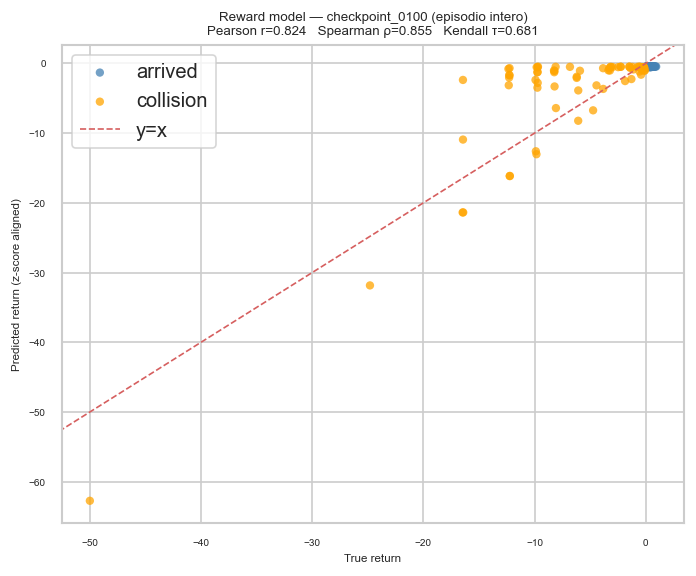

Pearson=0.824  Spearman=0.855  Kendall=0.681  n=299


(<Figure size 720x600 with 1 Axes>,
 <Axes: title={'center': 'Reward model — checkpoint_0100 (episodio intero)\nPearson r=0.824   Spearman ρ=0.855   Kendall τ=0.681'}, xlabel='True return', ylabel='Predicted return (z-score aligned)'>)

In [7]:
segments_full = _extract_segments(trajectories, segment_length=None)

plot_scatter_from_segments(
    segments_full,
    reward_models[CKPT_ID],
    normalize=True,
    robust=False,
    title=f"Reward model — {checkpoint_dirs[CKPT_ID].name} (episodio intero)",
)

### 3b — Scatter per diverse lunghezze di segmento

Mostra come cambia la correlazione in funzione della granularità con cui si confrontano i segmenti.

AttributeError: `ptp` was removed from the ndarray class in NumPy 2.0. Use np.ptp(arr, ...) instead.

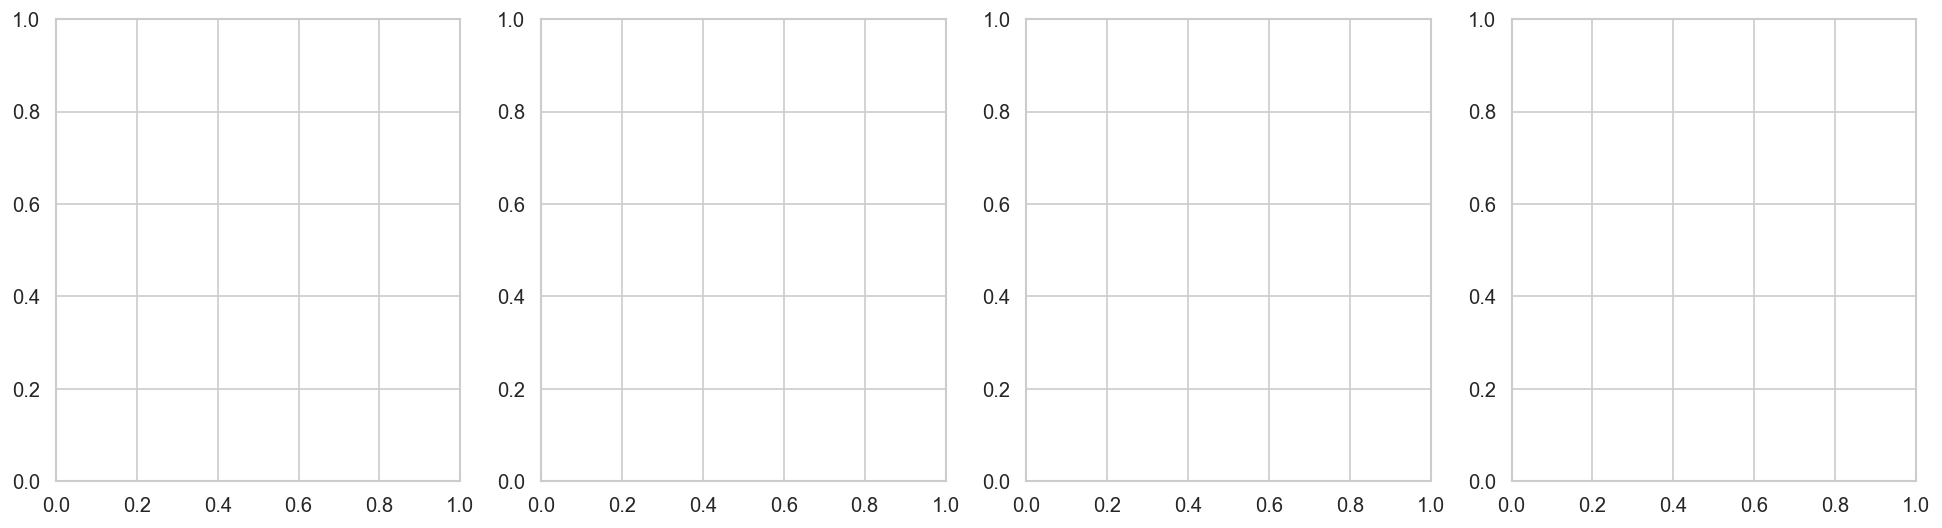

In [ ]:
SEG_LENS = [1, 5, 20, None]
SEG_LABELS = {1: "1 step", 5: "5 step", 20: "20 step", None: "episodio intero"}

fig, axes = plt.subplots(1, len(SEG_LENS), figsize=(5 * len(SEG_LENS), 5), squeeze=False)

all_scores = []
for sl in SEG_LENS:
    segs = _extract_segments(trajectories, segment_length=sl)
    all_scores.append(_score_and_normalize(segs, reward_models[CKPT_ID], normalize=True, robust=False))

all_true = np.concatenate([s[0] for s in all_scores])
all_pred = np.concatenate([s[1] for s in all_scores])
pad = (np.ptp(all_true) + np.ptp(all_pred)) * 0.02
xlim = (all_true.min() - pad, all_true.max() + pad)
ylim = (all_pred.min() - pad, all_pred.max() + pad)

STATUS_COLORS = {
    0: "steelblue", 1: "orange", 2: "crimson", 3: "mediumpurple",
    4: "gray", 5: "gold", 6: "saddlebrown",
}
STATUS_LABELS = {
    0: "arrived", 1: "collision", 2: "off_road", 3: "timeout",
    4: "running", 5: "teleported", 6: "removed",
}

for ax, sl, (true_r, pred_r, term_s, pr, sr, kt) in zip(axes[0], SEG_LENS, all_scores):
    for sid, color in STATUS_COLORS.items():
        m = term_s == sid
        if m.any():
            ax.scatter(true_r[m], pred_r[m], color=color, alpha=0.6, s=12,
                       edgecolors="none", label=STATUS_LABELS[sid])
    lo = min(xlim[0], ylim[0])
    hi = max(xlim[1], ylim[1])
    ax.plot([lo, hi], [lo, hi], "r--", lw=1)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_title(f"{SEG_LABELS[sl]}\nr={pr:.2f}  ρ={sr:.2f}  τ={kt:.2f}  n={len(true_r)}", fontsize=9)
    ax.set_xlabel("True return", fontsize=8)
    ax.set_ylabel("Pred return (z-score aligned)", fontsize=8)

handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(handles), fontsize=8, frameon=False)
plt.suptitle(f"Qualità reward model per lunghezza segmento — {checkpoint_dirs[CKPT_ID].name}", fontsize=11)
plt.tight_layout(rect=[0, 0.06, 1, 0.97])
plt.show()

### 3c — Reward curves: step-by-step per alcuni episodi

Per ogni episodio: reward reale vs predetto (± deviazione standard dell'ensemble) passo per passo.

In [ ]:
N_TRAJ_CURVES = 5  # numero di episodi da visualizzare

plot_reward_curves(
    trajectories[:N_TRAJ_CURVES],
    reward_models[CKPT_ID],
    normalize=True,
    robust=False,
)

## 4 — Confronto tra checkpoint

### 4a — Griglia scatter: tutti i checkpoint su assi condivisi

In [ ]:
plot_scatter_checkpoints(
    RUN_DIR,
    segments_full,
    load_fn=load_reward_ensemble,
    obs_space=env.observation_space,
    act_space=env.action_space,
    n_cols=5,
    normalize=True,
    robust=False,
)

### 4b — Correlazione (Kendall τ, Spearman ρ) vs iterazione

Curva di apprendimento del reward model: mostra se la qualità aumenta con il training.

In [ ]:
pearson_vals, spearman_vals, kendall_vals = [], [], []

for rm in reward_models:
    _, _, _, pr, sr, kt = _score_and_normalize(
        segments_full, rm, normalize=True, robust=False
    )
    pearson_vals.append(pr)
    spearman_vals.append(sr)
    kendall_vals.append(kt)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ckpt_iterations, pearson_vals,  marker="o", label="Pearson r",   lw=1.5)
ax.plot(ckpt_iterations, spearman_vals, marker="s", label="Spearman ρ",  lw=1.5)
ax.plot(ckpt_iterations, kendall_vals,  marker="^", label="Kendall τ",   lw=1.5)
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("Iterazione")
ax.set_ylabel("Correlazione")
ax.set_title("Qualità reward model nel corso del training (episodio intero, z-score aligned)")
ax.legend()
plt.tight_layout()
plt.show()

## 5 — Dinamiche di training (WandB)

Questa sezione legge la storia completa delle metriche per iterazione dal run WandB.

### Come accedere ai log WandB

1. Installa il client se non presente: `pip install wandb`
2. Autentica con `wandb login` nel terminale (oppure imposta la variabile `WANDB_API_KEY`)
3. I parametri `WANDB_ENTITY`, `WANDB_PROJECT`, `WANDB_RUN_ID` sono già pre-compilati per questo run.
   Modificali se stai analizzando un run diverso.

In [ ]:
WANDB_ENTITY = "andrea02polimi-politecnico-di-milano"
WANDB_PROJECT = "PPO_demo"
WANDB_RUN_ID = "e04wxf42"

import wandb

api = wandb.Api()
run = api.run(f"{WANDB_ENTITY}/{WANDB_PROJECT}/{WANDB_RUN_ID}")

# Scarica tutta la storia delle metriche come DataFrame pandas
history = run.history(samples=10_000)  # samples alto per avere tutti i punti

print(f"Run: {run.name}  |  Stato: {run.state}")
print(f"Step totali: {run.summary.get('agent/time/total_timesteps', 'n/a')}")
print(f"Righe nella history: {len(history)}")
print(f"Colonne disponibili: {list(history.columns)}")

In [ ]:
# Filtra le righe con il contatore di iterazioni (alcune righe WandB sono agent-internal)
hist = history.dropna(subset=["iterations"]).copy()
hist = hist.sort_values("iterations").reset_index(drop=True)
print(f"Righe con 'iterations': {len(hist)}  (iterazioni: {hist['iterations'].min():.0f}–{hist['iterations'].max():.0f})")

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
iters = hist["iterations"]

# ── Plot 1: MaxEnt IRL loss ──────────────────────────────────────────────────
ax = axes[0, 0]
if "reward/loss_val" in hist.columns:
    ax.plot(iters, hist["reward/loss_val"], color="tomato", lw=1.5)
    ax.set_title("MaxEnt IRL Loss")
    ax.set_xlabel("Iterazione")
    ax.set_ylabel("Loss")
else:
    ax.set_title("MaxEnt IRL Loss (dati non disponibili)")

# ── Plot 2: Mean true reward ─────────────────────────────────────────────────
ax = axes[0, 1]
if "rollout/mean_true_reward" in hist.columns:
    ax.plot(iters, hist["rollout/mean_true_reward"], color="steelblue", lw=1.5, label="true")
if "rollout/mean_model_reward" in hist.columns:
    ax.plot(iters, hist["rollout/mean_model_reward"], color="tomato", lw=1.5, ls="--", label="model")
ax.set_title("Reward medio per rollout")
ax.set_xlabel("Iterazione")
ax.set_ylabel("Reward medio")
ax.legend()

# ── Plot 3: Kendall τ su step running ────────────────────────────────────────
ax = axes[1, 0]
if "reward_val/current_rollout/kendall_running" in hist.columns:
    ax.plot(iters, hist["reward_val/current_rollout/kendall_running"], color="mediumpurple", lw=1.5)
    ax.axhline(0, color="gray", lw=0.8, ls="--")
    ax.set_title("Kendall τ — step running")
    ax.set_xlabel("Iterazione")
    ax.set_ylabel("Kendall τ")
else:
    ax.set_title("Kendall τ running (dati non disponibili)")

# ── Plot 4: Event rates ───────────────────────────────────────────────────────
ax = axes[1, 1]
event_cols = {
    "agent/event_rate/successes" : ("steelblue",     "successi"),
    "agent/event_rate/collisions": ("orange",        "collisioni"),
    "agent/event_rate/off_road"  : ("crimson",       "off-road"),
    "agent/event_rate/timeouts"  : ("mediumpurple",  "timeout"),
}
for col, (color, label) in event_cols.items():
    if col in hist.columns:
        ax.plot(iters, hist[col], color=color, lw=1.5, label=label)
ax.set_title("Event rates agente")
ax.set_xlabel("Iterazione")
ax.set_ylabel("Tasso")
ax.legend(fontsize=8)

plt.suptitle(f"Dinamiche di training — {run.name}", fontsize=12)
plt.tight_layout()
plt.show()